# LEAP Momentum bootcamp

## Generative Models for Climate — Practical

This notebook walks through Langevin Monte Carlo and score-based diffusion models, from a low-dimensional
toy system up to a conditional sampler for a chaotic dynamical system. It is organized as follows.

| Section | Topic |
|---|---|
| 1 | Langevin dynamics: sampling a known 2D density (double well × Gaussian) |
| 2 | A diffusion model: learning the score of a 2D mixture and sampling from it |
| 3 | A 3D diffusion model for the Lorenz 63 attractor |
| 4 | Application to an inverse problem: conditional sampling for data assimilation |

All the functions and algorithms, including the bits to be filled, are written in separate python modules. This notebook imports and assembles them, and serves as a tool to visualize the results.

> **About this practical.** The cells below import functions from the project's
> python modules (`sampling/`, `learning/`, ...). Inside several of those files a
> pedagogically central function ships in two versions side by side: a
> **student version** (with the key lines replaced by hints and a
> `raise NotImplementedError("Q...")`) and a working version, one commented out
> and the other active. Each section opens with a **Question** box telling you
> exactly which file to open, which function to fill in, and the formula to
> implement. Once a question is filled, the downstream cells should run
> end-to-end without further changes.


## Environment check

Run the cell below first. It installs any missing dependency (when run on a fresh kernel like Colab) and prints the version of every library used in this notebook.


In [1]:
# If any import fails (e.g. on a fresh Colab kernel), uncomment and run:
# %pip install --quiet numpy torch matplotlib scipy tqdm

import importlib

_required = [
    ("numpy", "np"),
    ("torch", None),
    ("matplotlib", None),
    ("scipy", None),
    ("tqdm", None),
]

for _name, _ in _required:
    _mod = importlib.import_module(_name)
    print(f"{_name:12s} {getattr(_mod, '__version__', 'unknown')}")


import matplotlib.pyplot as plt 
import torch as _torch
assert _torch.zeros(3).sum().item() == 0.0
print("all imports OK")


numpy        2.3.3
torch        2.12.0
matplotlib   3.10.7
scipy        1.16.3
tqdm         4.67.1
all imports OK


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import plot

%matplotlib inline

# Compact figure + smaller fonts so cells render at a sensible size in-notebook.
plt.rcParams["figure.figsize"] = (6, 3.2)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 8
plt.rcParams["axes.titlesize"] = 9
plt.rcParams["axes.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 7
plt.rcParams["xtick.labelsize"] = 7
plt.rcParams["ytick.labelsize"] = 7

device = "cpu"  # the models are tiny MLPs; CPU is fastest & fully reproducible
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__, "| device:", device)

torch 2.12.0 | device: cpu


## Section 1 — Langevin Dynamics

Our target is the Gibbs (Boltzmann) distribution of a 2D potential: the
asymmetric double well in $x$, plus an independent harmonic (Gaussian) trap in
$y$. The target density takes the form

$$p(x) \propto e^{-f(x)},$$

for $x \in \mathbb{R}^2$, with

$$f(x) = x_1^4 - 2x_1^2 + 0.3x_1 + \tfrac12 k\, x_2^2.$$

Let us first look at the target density itself, before trying to sample from it. It has two wells along $x_1$, with a Gaussian shape in $x_2$.

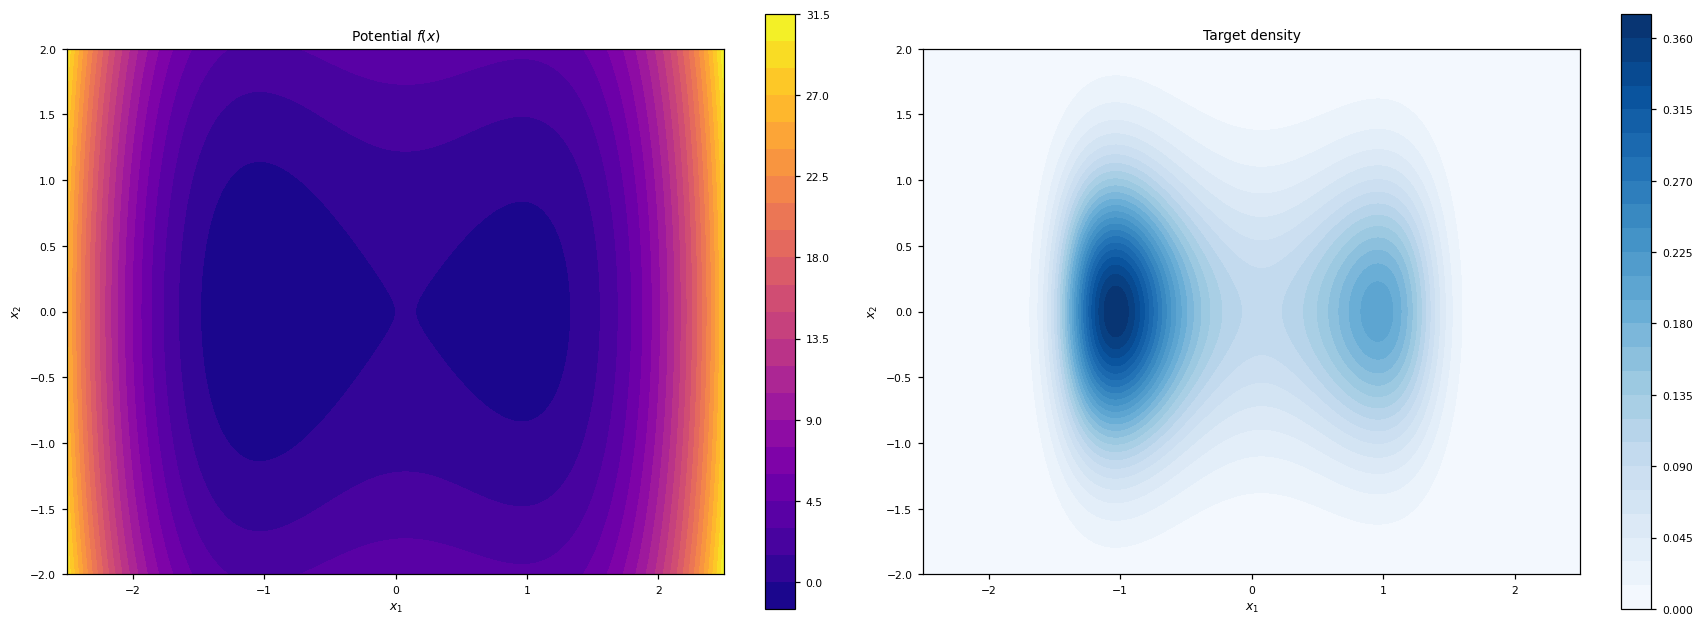

In [3]:
from data_distributions import double_well_gaussian_2d as double_well

x_axis = np.linspace(-2.5, 2.5, 300)
y_axis = np.linspace(-2.0, 2.0, 240)
grid_x, grid_y = np.meshgrid(x_axis, y_axis)
grid_points = np.stack([grid_x, grid_y], axis=-1)

potential_grid = double_well.potential(grid_points)
density_grid = double_well.gibbs_density(grid_points)

# The target density, on its own (no samples yet).
plot.potential_and_density_2d(grid_x, grid_y, potential_grid, density_grid)

To draw samples from this density we use the Langevin Monte Carlo Algorithm. This algorithm requires the gradient $\nabla f$, which is here a 2D vector field. The sampling iterations are

$$ y_{k+1} =  y_k - \eta\,\nabla f( y_k)
+ \sqrt{2\eta}\, w_k,
\qquad w_k \sim \mathcal N(0, I_2).$$

Running many independent chains in parallel fills **both** wells; we then overlay
the generated samples on the density to check they agree.

### Question 1.1 — Implement the Langevin update rule

**File:** `sampling/langevin.py` &nbsp; **Function:** `langevin_sample`

Inside the for-loop, write the two lines that perform one ULA step. The
discretized overdamped Langevin SDE reads

$$x_{k+1} = x_k - \eta\,\nabla U(x_k) + \sqrt{2\eta\tau}\,\varepsilon_k,
\qquad \varepsilon_k \sim \mathcal{N}(0, I).$$

Specifically:

1. Draw `eps = rng.standard_normal(size=x.shape)` — i.i.d. Gaussian noise
   with the same shape as the batch of chains `x`.
2. Update `x = x - eta * grad_U(x) + noise_scale * eps`, where the scalar
   `noise_scale = sqrt(2 * eta * tau)` is already pre-computed above the loop.

**What to check.** Once filled, the next plot should show the empirical
histogram of the chains overlaying the analytic Gibbs density across **both**
wells (the deeper one carrying more mass). If only one well is populated,
you likely forgot the noise term — without it the chain is pure gradient
descent and gets trapped in the closer minimum.

100%|██████████| 3000/3000 [00:00<00:00, 5204.79it/s]


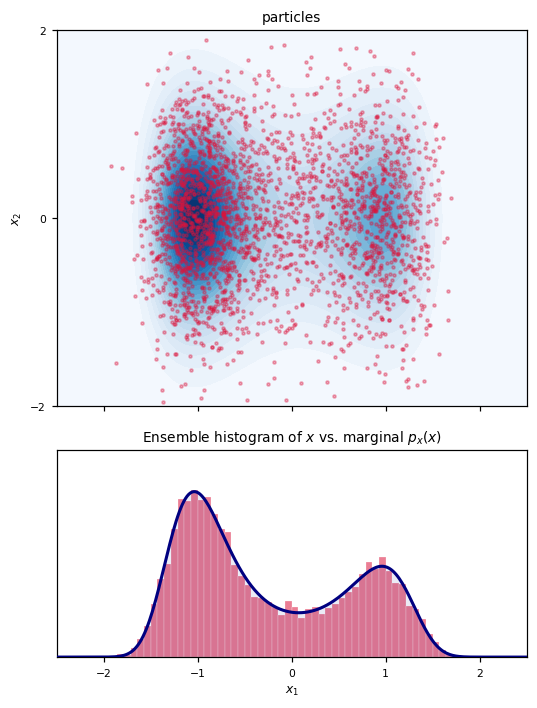

In [5]:
from sampling.langevin import langevin_sample

# Many independent ULA chains from a broad uniform spread, so BOTH wells fill.
rng = np.random.default_rng(0)
initial_states = rng.uniform([-2.0, -1.5], [2.0, 1.5], size=(8000, 2))
langevin_samples = langevin_sample(double_well.grad_potential, initial_states,
                                   eta=5e-3, n_steps=3000, rng=rng)

# Same 2D-contour + 1D-marginal layout the animation scripts use, drawn once
# at the final ensemble state.
plot.density_marginal_snapshot(
    (grid_x, grid_y, density_grid), x_axis, double_well.x_marginal(x_axis),
    langevin_samples, xlim=(-2.5, 2.5), ylim=(-2.0, 2.0))


## Section 2 — Learning to Sample: a 2D Gaussian Mixture

In Section 1, the analytic expression of the target density was known, which allowed us to compute the Langevin iterations with the potential gradient $\nabla f(x)$.

Generative-modeling aims at learning the data distribution from samples, and to draw new ones, without an analytical model. 

In this section, we learn a diffusion model on a two-dimensional bimodal data distribution.

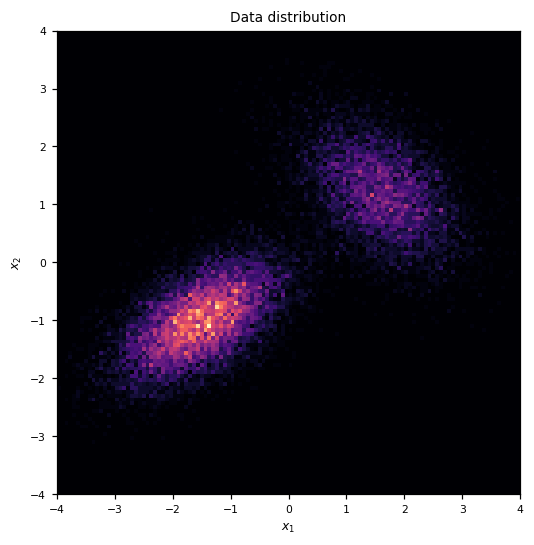

In [6]:
from data_distributions import gaussian_mixture_2d as mixture


mixture_data = mixture.sample(20000, rng=np.random.default_rng(0)).astype(np.float32)

plot.samples_2d(mixture_data, title="Data distribution")

 The point cloud has two well-separated, tilted blobs
of unequal mass, generated from a mixture of two Gaussians

$$p(x) = w_1\,\mathcal N(x;\mu_1,\Sigma_1) + w_2\,\mathcal N(x;\mu_2,\Sigma_2),
\qquad (w_1,w_2) = (0.65,\,0.35).$$

Being a mixture, it is exactly samplable and its score is known in closed
form — the responsibility-weighted blend of the two linear scores,

$$\nabla\log p(x) = -\sum_k r_k(x)\,\Sigma_k^{-1}(x-\mu_k),
\qquad r_k(x) = \frac{w_k\,\mathcal N_k(x)}{\sum_j w_j\,\mathcal N_j(x)}.$$


Our goal here is to sample from this toy bimodal data distribution.


### A failure mode for Langevin Monte Carlo? 

We have $\nabla\log p$ in closed form, so we could try to  sampler
directly. But the two components are far apart, separated by a deep
low-density valley where the score $\nabla\log p \approx 0$. In this area, the chain gets almost
no push across. Within any practical budget it stays trapped in whichever
mode it started in.

The number of steps required to cross a potential barrier can be shown to be exponential in the potential difference.

Let's run the  Langevin Monte Carlo algorithm from a
uniform start and compare the empirical histograms of the data and of
Langevin, for the first component $x_1$.


In [7]:
rng = np.random.default_rng(0)
initial_states = rng.uniform(-4, 4, size=(8000, 2))
langevin_samples = langevin_sample(mixture.grad_potential, initial_states,
                                   eta=3e-3, n_steps=3_000, rng=rng)


100%|██████████| 3000/3000 [00:08<00:00, 356.09it/s]


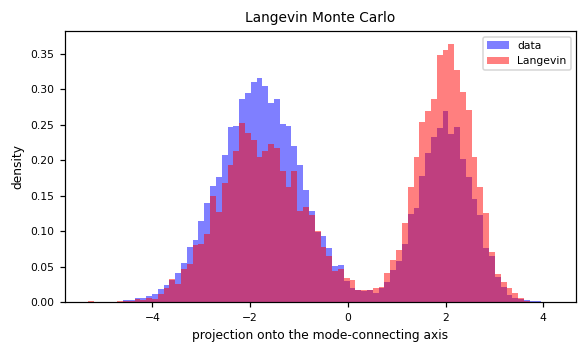

In [8]:
plot.two_hists(mixture_data, langevin_samples,
               labels=("data", "Langevin"),
               title="Langevin Monte Carlo")

### A score-based diffusion model

A diffusion model never has to cross the barrier. We define a noise schedule
connecting pure noise at $t=0$ to the data at $t=1$,

$$x_t = \mu_t\, x_0 + \sigma_t\,\varepsilon,
\qquad \mu_t^2 + \sigma_t^2 = 1,$$



so that at initial time $\mu_0\approx 0,\ \sigma_0\approx 1$ models a single Gaussian blob, and at terminal time
$\mu_1 = 1,\ \sigma_1 = 0$ models the data distribution.

Throughout, the diffusion model runs **forward in
time**: $t=0$ is pure noise and $t=1$ is the data, so generation flows from noise
up to the learned density.

Generation runs forward in time: we
start from one Gaussian blob at $t=0$ and integrate the generative SDE up to
$t=1$, where the blob has split into both modes in the proportion the score
network learned from data — the relative weight is baked into $s_\theta(x,t)$, not
discovered by hopping.

### Question 2.1 — Implement the VP noise schedule

**File:** `sampling/schedule.py` &nbsp; **Functions:** `mu_t`, `sigma_t`

We use the **generative-time** convention: $t=0$ is pure noise, $t=1$ is the
clean data. With the integrated noise rate
$B(s) = \beta_{\min}s + \tfrac12(\beta_{\max}-\beta_{\min})s^2$ (already
provided as `_corruption_integral`), implement

$$\mu_t = \exp\!\bigl(-\tfrac12 B(1-t)\bigr), \qquad
\sigma_t = \sqrt{\,1 - \mu_t^{\,2}\,}.$$

Use the provided `_exp` wrapper so the same function works for both numpy
arrays (training-data plotting) and torch tensors (training loop). Clip the
argument of the square root to a tiny positive number (e.g. `1e-20`) before
taking the root.

**What to check.** Running the next cell should plot two monotone curves on
$[0,1]$: $\mu_t$ going from $\sim 0$ at $t=0$ up to $1$ at $t=1$, and
$\sigma_t$ going from $\sim 1$ at $t=0$ down to $0$ at $t=1$, with
$\mu_t^2 + \sigma_t^2 = 1$ at every $t$.

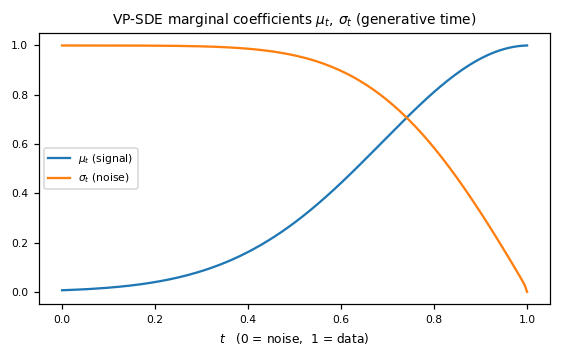

In [9]:
from sampling.schedule import mu_t, sigma_t

times = torch.linspace(0, 1, 200)
plot.noise_schedule(times, mu_t(times), sigma_t(times))

### Training (denoising score matching)

We fit $s_\theta(x_t,t)\approx
-\varepsilon/\sigma_t$ by minimizing the $\sigma_t^2$-weighted loss
$\|\sigma_t s_\theta + \varepsilon\|^2$. We first standardize the data, since the
noise schedule targets unit variance.

### Question 2.2 — Implement the denoising score matching (DSM) loss

**File:** `learning/training.py` &nbsp; **Function:** `dsm_loss`

For a clean batch $x_0$, sample a random time $t \sim \mathcal{U}(0, 1)$ and a
noise vector $\varepsilon \sim \mathcal{N}(0, I)$, then form the noised sample
$x_t = \mu_t x_0 + \sigma_t\,\varepsilon$. Tweedie's formula tells us the
conditional score of the Gaussian transition kernel is $-\varepsilon/\sigma_t$,
so the loss is

$$\mathcal{L}(\theta) = \mathbb{E}\,\big\| s_\theta(x_t, t) + \varepsilon/\sigma_t \big\|^2
\quad\xrightarrow{\times \sigma_t^2}\quad
\mathbb{E}\,\big\| \sigma_t s_\theta(x_t, t) + \varepsilon \big\|^2.$$

The $\sigma_t^2$-weighted form on the right has the **same minimizer** but
stays well-scaled as $t \to 1$ (where $\sigma_t \to 0$); that is the one we
train with (`weighted=True`).

Specifically, fill in the body to:

1. Draw `eps = torch.randn_like(x0)`.
2. Build `x_t = mu * x0 + sigma * eps` (the `mu`, `sigma` of shape `(B, 1)`
   are already pre-computed and broadcast across the feature dimension).
3. Evaluate `score = model(x_t, t)`.
4. Build `residual = sigma * score + eps` (if `weighted`) else
   `residual = score + eps / sigma`, and return `(residual**2).sum(-1).mean()`.

**What to check.** The training-loss curve should drop quickly over the
first few hundred steps and then plateau — a flat or NaN curve almost
always means a shape bug in step 2 or 4.

100%|██████████| 3000/3000 [00:04<00:00, 662.92it/s]


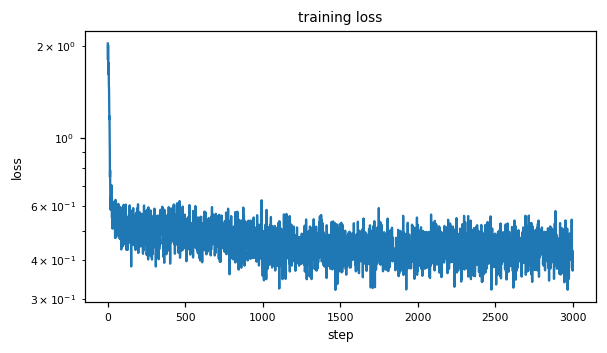

In [10]:
from learning.networks import ScoreNet2D
from learning.training import train_score_model

# Standardize per-dimension (the noise schedule targets unit variance).
data_mean, data_std = mixture_data.mean(0), mixture_data.std(0)
mixture_data_standardized = (mixture_data - data_mean) / data_std

score_model = ScoreNet2D().to(device)
score_model, losses = train_score_model(score_model, mixture_data_standardized,
                                        n_epochs=3000, batch_size=512, lr=1e-3)

plot.loss_curve(losses, title="training loss", log=True)

**Reading the field.** At the data end $t\approx1$ the network should recover
the *data* score $\nabla\log p$: arrows point *uphill in probability*, flowing
into the two Gaussian blobs and away from the low-density valley between them. We
draw each arrow as a unit-length **direction** colored by magnitude, so the
geometry stays readable even where the score is large. The analytic field (left)
is the closed-form mixture score; the learned one (right) is what denoising score
matching recovered.

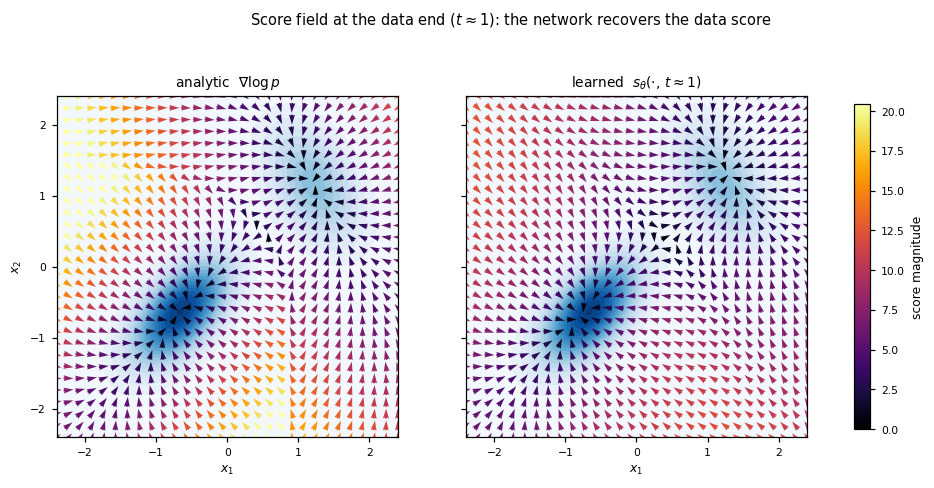

In [11]:
plot.score_fields(score_model, mixture.score, mixture.gibbs_density,
                  data_mean, data_std)

**Across noise levels.** The score depends on *how noisy* its input is. Here we
sweep the **added-noise level $\sigma$** directly (rather than time): the noised
density $p_\sigma$ is the data blurred by a Gaussian of width $\sigma$ (and shrunk
by $\mu=\sqrt{1-\sigma^2}$). At small $\sigma$ the field shows the two-basin
structure of the data score; as $\sigma$ grows the two blobs contract and **merge
into a single Gaussian**, and the learned field collapses to one inward pull
toward the origin. This merging at high noise is exactly what lets generation
start from a single blob and avoid the barrier that trapped Langevin above.

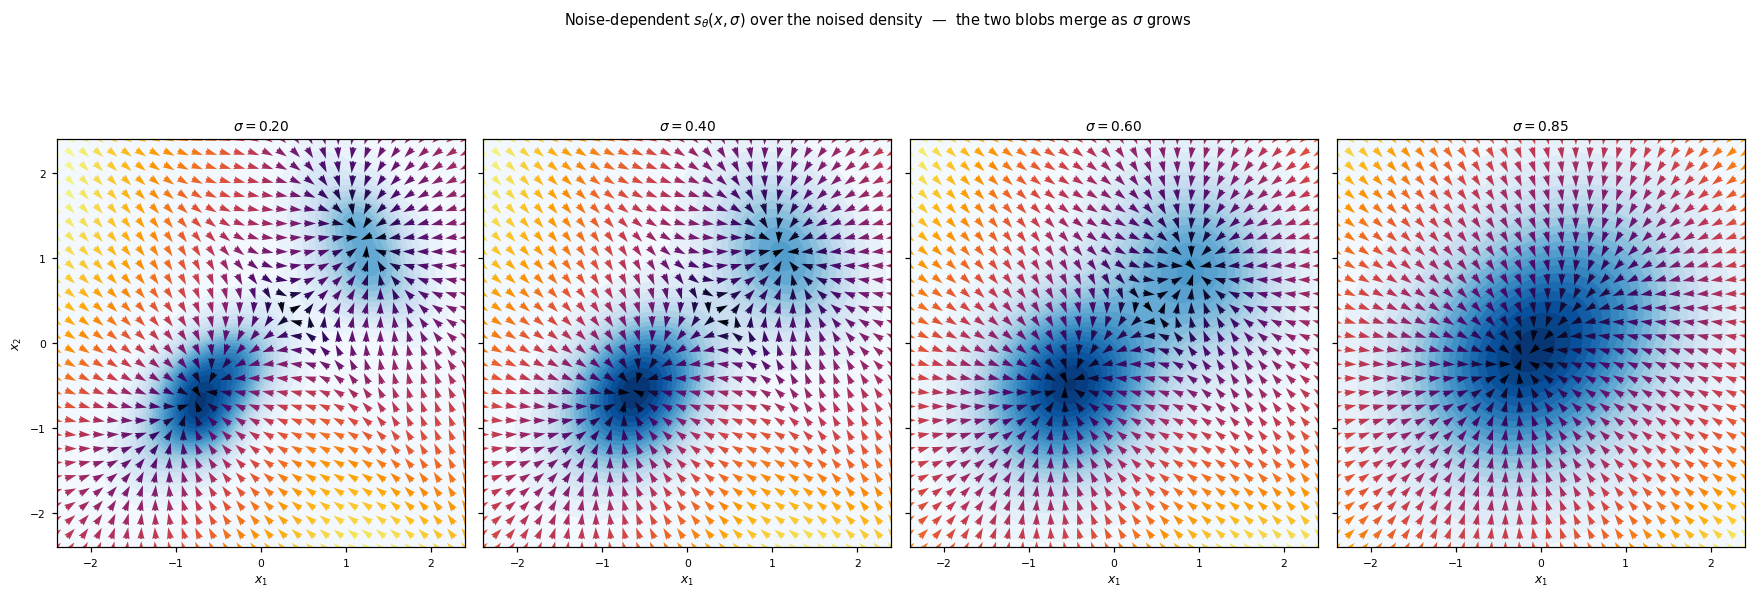

In [12]:
plot.field_across_noise(score_model, mixture_data_standardized,
                        sigma_levels=[0.2, 0.4, 0.6, 0.85])

### Question 2.3 — Implement the generative SDE step

**File:** `sampling/diffusion_sampler.py` &nbsp; **Function:** `generate_samples`

We sample by integrating the generative VP-SDE **forward in time**, from
noise $x(0) \sim \mathcal{N}(0, I)$ to data at $t = 1$:

$$dx = \bigl[\,\tfrac12 \beta(t)\,x + \beta(t)\,s_\theta(x, t)\,\bigr]\,dt
+ \sqrt{\beta(t)}\,dw.$$

Inside the loop, implement one Euler–Maruyama step:

1. `score = model(x, t_batch)`.
2. `drift = 0.5 * beta_t * x + beta_t * score`.
3. `x = x + drift * dt`.
4. *On every step except the last*, add a Brownian increment
   `x = x + torch.sqrt(beta_t * dt) * torch.randn_like(x)`. Dropping the noise
   on the last step is a standard "final-denoise" trick.

**What to check.** Once filled, both the 2D mixture sampler (Section 2) and
the 3D Lorenz sampler (Section 3) start working: the mixture cell should
show generated points covering both blobs in roughly $65/35$ proportion, and
the Lorenz cell should trace out the butterfly attractor. Common bugs:
missing the noise term collapses the sampler to its deterministic
*probability-flow ODE*, which still looks reasonable but loses diversity.

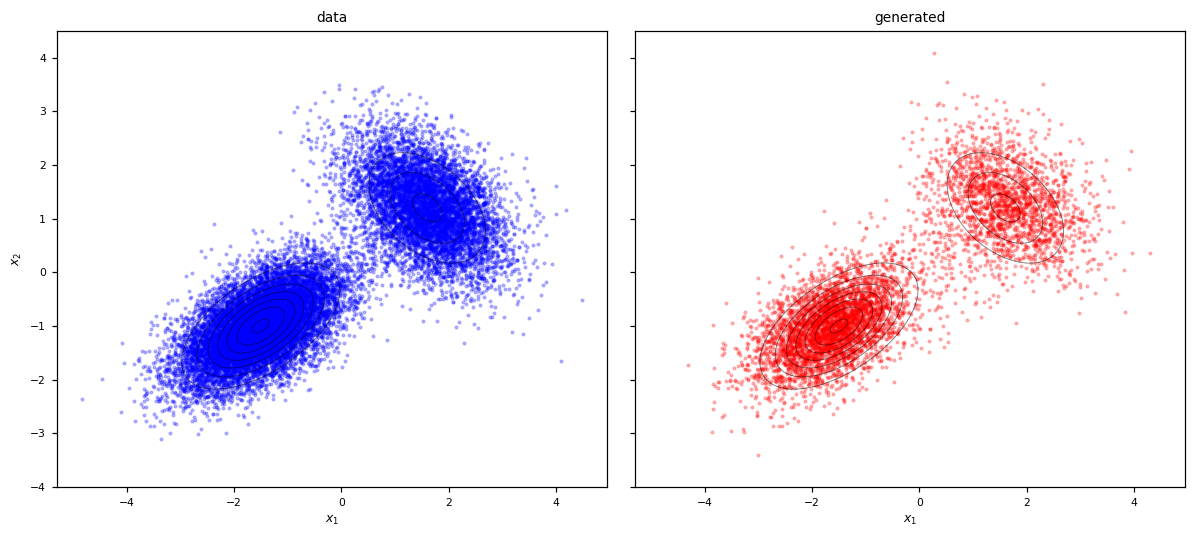

In [13]:
from sampling.diffusion_sampler import generate_samples

x_axis = np.linspace(-4.0, 4.0, 240)
grid_x, grid_y = np.meshgrid(x_axis, x_axis)
density_grid = mixture.gibbs_density(np.stack([grid_x, grid_y], axis=-1))

# Generate by integrating the generative SDE forward in time, then un-standardize.
generated_samples = generate_samples(score_model, n_samples=6000, dim=2,
                                      n_steps=1000, seed=0)
generated_samples = generated_samples.cpu().numpy() * data_std + data_mean

plot.samples_comparison_2d((grid_x, grid_y, density_grid), mixture_data,
                           generated_samples,
                           titles=("data", "generated"))


**Why diffusion gets it right.** The generative process never has to cross the
barrier. Run forward in time, it **starts from a single Gaussian blob** at $t=0$
and **splits** it into both modes by $t=1$, in the proportion the score network
learned from data — the relative weight is baked into $s_\theta(x,t)$ at every
noise level. This robustness to separated, unequally-weighted modes is a core
reason to prefer score-based diffusion over plain Langevin on multimodal targets.

## Section 3 — Lorenz '63 Diffusion Model

We now scale up to 3D. The **Lorenz '63** system is chaotic; points along a long
trajectory sample its invariant measure — the two-winged *butterfly attractor*.
We train a `ScoreNet3D` on this point cloud and then **generate** new states by
running the diffusion model forward in time (from noise at $t=0$ to data at
$t=1$). Good samples should re-trace the butterfly.

training cloud: (22000, 3)


100%|██████████| 4000/4000 [00:12<00:00, 309.45it/s]


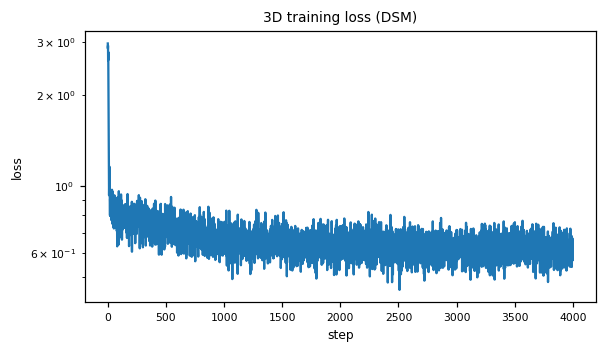

In [ ]:
from data_distributions.lorenz import simulate_attractor
from learning.networks import ScoreNet3D

lorenz_data = simulate_attractor(n_steps=25000, dt=0.01, burn_in=3000).astype(np.float32)
lorenz_mean, lorenz_std = lorenz_data.mean(0), lorenz_data.std(0)
lorenz_data_standardized = (lorenz_data - lorenz_mean) / lorenz_std
print("training data shape:", lorenz_data.shape)

score_model_3d = ScoreNet3D().to(device)
score_model_3d, losses_3d = train_score_model(score_model_3d, lorenz_data_standardized,
                                              n_epochs=4000, batch_size=512, lr=1e-3)
plot.loss_curve(losses_3d, title="3D training loss (DSM)", log=True)

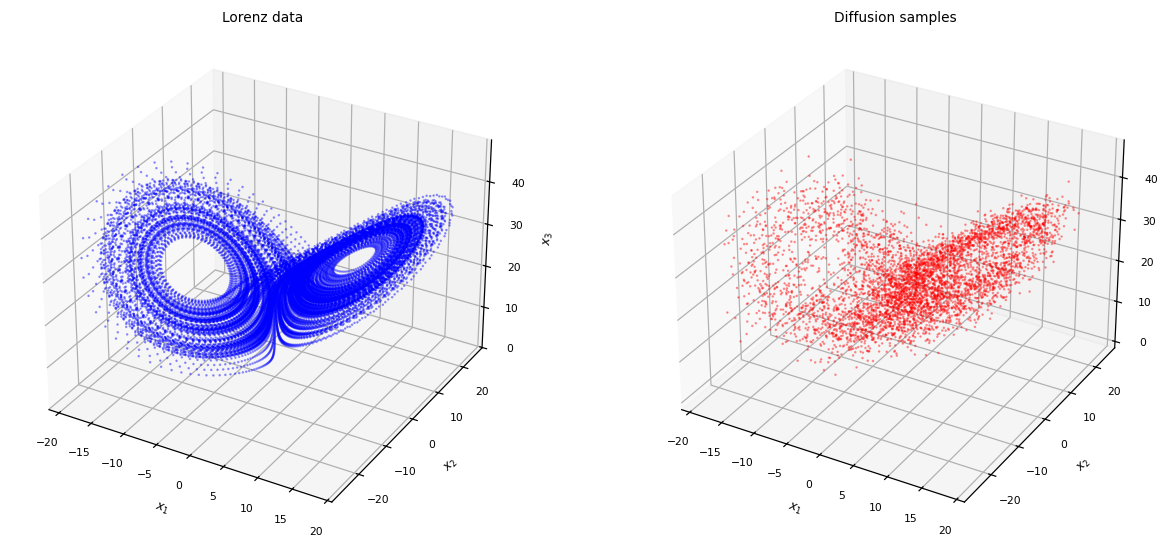

In [15]:
generated_standardized = generate_samples(score_model_3d, n_samples=5000, dim=3,
                                          n_steps=1000, seed=0)
generated_states = generated_standardized.cpu().numpy() * lorenz_std + lorenz_mean

plot.comparison_3d(lorenz_data, generated_states)

## Section 4 — Inverse Problem: Conditional Sampling

Finally, a data-assimilation flavored task. We observe **only the z-component**
of a hidden Lorenz state, through a noisy linear sensor

$$y = Hx + \nu,\quad H=[0,0,1],\quad \nu\sim\mathcal N(0,\sigma_{\text{obs}}^2).$$

We want the **posterior** $p(x\mid y)$. By Bayes, its score is just a sum:

$$\nabla_x\log p(x\mid y) = \underbrace{\nabla_x\log p(x)}_{s_\theta\ (\text{Section 3})}
+ \underbrace{\nabla_x\log p(y\mid x)}_{\text{closed-form Gaussian}}.$$

We plug this posterior score into the **same forward-time generative sampler**.
The butterfly attractor is left–right symmetric about the $z$-axis: for a given
$z$ value, states with that altitude exist on **both wings**. So $z$ alone cannot
tell us which lobe the truth is on, and the posterior over the full 3D state is
**bimodal** — the ensemble should split into the two wings, discriminated by the
sign of $x$.

### Question 4.1 — Implement the likelihood score

**File:** `sampling/inverse_problem.py` &nbsp; **Function:** `likelihood_score`

For a linear-Gaussian observation $y = Hx + \nu$ with
$\nu \sim \mathcal{N}(0, R)$ and $R = \sigma_{\text{obs}}^2 I$, the log-likelihood
is quadratic in $x$, so its gradient is the (precision-weighted) residual:

$$\nabla_x \log p(y \mid x) = H^\top R^{-1}(y - Hx)
= \frac{1}{\sigma_{\text{obs}}^2}\, H^\top (y - Hx).$$

Implement it in two lines using batched matmuls:

```python
residual = y - x @ H.T                # (B, m)
return  residual @ H / sigma_obs**2   # (B, d)
```

### Question 4.2 — Combine prior and likelihood (Bayes decomposition)

**Same file** &nbsp; **Function:** `compute_posterior_score` (the *likelihood-only* branch)

Bayes' rule gives a clean **additive** decomposition of scores:

$$\nabla_x \log p(x \mid y) = \underbrace{\nabla_x \log p(x)}_{s_\theta(x, t)}
\;+\; \underbrace{\nabla_x \log p(y \mid x)}_{\text{Q4.1}}.$$

The prior score `s_theta(x, t)` is already evaluated for you (`score = model(x, t_batch)`).
In the `else` branch (likelihood-only, where `B_inv is None`), just add the
likelihood score from Q4.1 and return:

```python
score = score + likelihood_score(x, y, H, sigma_obs)
return score
```

(Do *not* touch the `if B_inv is not None:` branch above — that is a more
advanced 3D-Var Gaussian-guidance variant that is shipped complete.)

**What to check.** The posterior ensemble should split into **both wings** of
the Lorenz butterfly: states with positive *and* negative $x$ both appear,
since the observation $z$ alone cannot tell the two lobes apart. A unimodal
result means the likelihood term is being applied too aggressively (or the
prior score got dropped); a result indifferent to $y$ means the likelihood
term was not added at all.

In [16]:
from sampling.inverse_problem import ObservationOperator, conditional_sample

# Pick a truth state on the attractor and synthesize a noisy z-observation.
# Sampling from the trajectory keeps the observation consistent with the prior.
truth = np.array([-19., -20.,  41.]
                 )                 # shape (3,)
observation_noise_std = 1.0                   # physical units
rng = np.random.default_rng(42)
z_obs = truth[2] + observation_noise_std * rng.standard_normal()
print(f"truth state: {truth.round(2)}   observed z: {z_obs:.2f}")

# The sampler works in standardized space, so standardize both y and sigma_obs
# along the z-coordinate (last column).
observation = ObservationOperator(sigma_obs=observation_noise_std / lorenz_std[2])
y_standardized = torch.tensor([(z_obs - lorenz_mean[2]) / lorenz_std[2]],
                              dtype=torch.float32)

posterior_standardized = conditional_sample(score_model_3d, y_standardized, observation,
                                            n_samples=2000, dim=3, n_steps=1000, seed=0)
posterior_samples = posterior_standardized.cpu().numpy() * lorenz_std + lorenz_mean

# Sign of x is the natural wing discriminator for the Lorenz butterfly.
wing_mask = posterior_samples[:, 0] > 0
print(f"posterior mean (xyz): {posterior_samples.mean(0).round(2)}")
print(f"posterior std  (xyz): {posterior_samples.std(0).round(2)}")
print(f"positive-x wing fraction: {wing_mask.mean():.2f}  "
      "(a well-calibrated posterior populates both lobes)")

truth state: [-19. -20.  41.]   observed z: 41.30
posterior mean (xyz): [ 3.2   2.36 40.77]
posterior std  (xyz): [12.45  7.44  0.71]
positive-x wing fraction: 0.62  (a well-calibrated posterior populates both lobes)


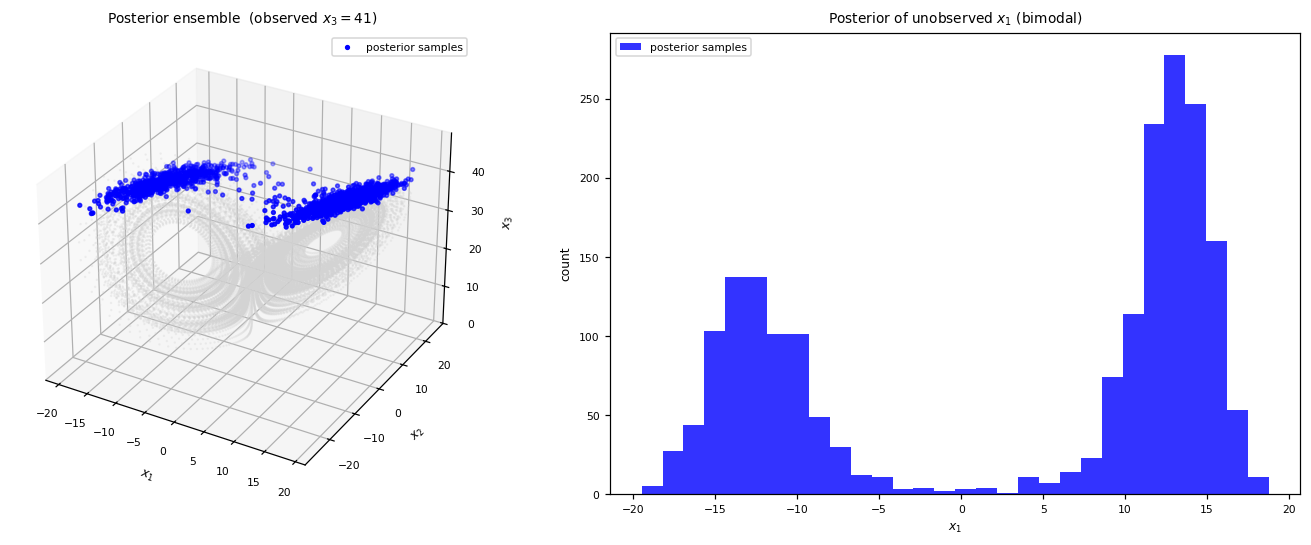

In [17]:
plot.posterior_ensemble(lorenz_data, posterior_samples, wing_mask, z_obs)

**Takeaway.** A single diffusion prior, trained once on the attractor, was
re-used to solve an inverse problem *without retraining*: we only added a
closed-form likelihood score. The posterior concentrates around the observed
$z$ while expressing genuine uncertainty about the unobserved $x,y$ — the
ensemble splits into both lobes of the butterfly, because $z$ alone cannot
distinguish them.